In [1]:
!pip install graphviz
!pip install matplotlib
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
  Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-macosx_10_15_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached numpy-2.5.2-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-macosx_10_15_univ

In [1]:
from micrograd.nn import MLP
from micrograd.utils import draw_compgraph
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles, make_moons
from micrograd.nn import MLP

X, y = make_circles(n_samples=100, noise=0.05, factor=0.5, random_state=42)

ys = [1.0 if label == 1 else -1.0 for label in y]
xs = X.tolist()

model = MLP(2, [16, 16, 1])  
epochs = 100

for epoch in range(epochs):
    
    ypred = [model(x) for x in xs]
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)) * (1.0 / len(ys))
    
    
    for param in model.parameters():
        param.grad = 0.0
    loss.backward()
    
    
    lr = 0.1 - (0.09 * epoch / epochs)
    for p in model.parameters():
        p.data -= lr * p.grad
        
    # Evaluation
    if epoch % 20 == 0 or epoch == epochs - 1:
        acc = sum((yout.data > 0) == (ygt > 0) for ygt, yout in zip(ys, ypred)) / len(ys)
        print(f"Epoch {epoch:3d} | Loss: {loss.data:.4f} | Accuracy: {acc*100:.1f}%")

Epoch   0 | Loss: 7.4058 | Accuracy: 50.0%
Epoch  20 | Loss: 0.4897 | Accuracy: 99.0%
Epoch  40 | Loss: 0.2969 | Accuracy: 99.0%
Epoch  60 | Loss: 0.1841 | Accuracy: 100.0%
Epoch  80 | Loss: 0.1294 | Accuracy: 100.0%
Epoch  99 | Loss: 0.1082 | Accuracy: 100.0%


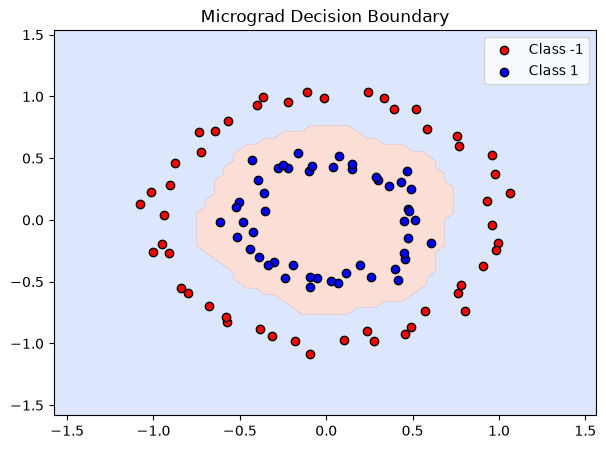

In [3]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 60), np.linspace(y_min, y_max, 60))

Z = np.array(
    [model([x, y]).data for x, y in zip(xx.ravel(), yy.ravel())]
).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z > 0, alpha=0.3, cmap="coolwarm")
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="red", label="Class -1", edgecolors="k")
plt.scatter(
    X[y == 1, 0], X[y == 1, 1], c="blue", label="Class 1", edgecolors="k"
)
plt.title("Micrograd Decision Boundary")
plt.legend()
plt.show()

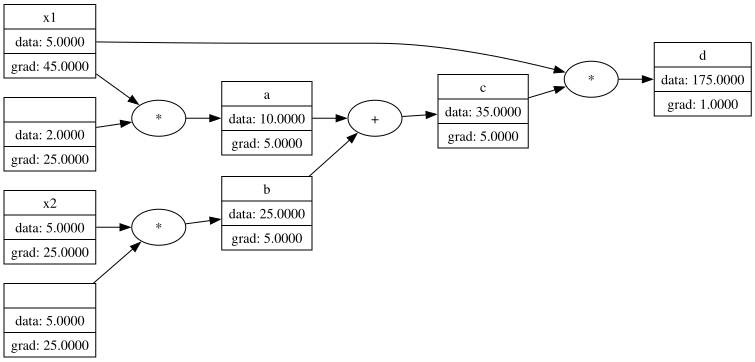

In [1]:
from micrograd.utils import draw_compgraph
from micrograd.engine import Value

x1 = Value(5, label="x1")
x2 = Value(5, label="x2")
a = (x1*2); a.label="a"
b = (x2*5); b.label="b" 
c = a+b; c.label="c"
d = c*x1; d.label="d"

d.backward()

draw_compgraph(d,True)